# Reconocimiento de Dígitos con Redes Neuronales Convolucionales (CNN)
---
## 1. Business Case Discovery

### 1.1 Contexto del Negocio y Antecedentes
Una importante compañía de envíos busca modernizar su sistema de ruteo de correspondencia mediante el reconocimiento automático de códigos postales. Actualmente, el proceso manual genera demoras y errores operativos. 

### 1.2 Objetivo del Proyecto
Desarrollar un sistema basado en redes neuronales convolucionales (CNN) que identifique correctamente los dígitos en imágenes de paquetes, automatizando la clasificación según el código postal.

### 1.3 Métricas de Éxito
- **Precisión (Accuracy):** Porcentaje de dígitos reconocidos correctamente.
- **Tiempo de Inferencia:** Velocidad de procesamiento por imagen.
- **Número de Parámetros:** Eficiencia y capacidad de generalización del modelo.

---

## 2. Preparación del Entorno
Importamos las librerías necesarias para el procesamiento de datos, construcción del modelo y visualización.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 3. Data Processing (Procesamiento de Datos)

### 3.1 Carga del Dataset MNIST
Utilizaremos el dataset MNIST, que contiene 70,000 imágenes de dígitos manuscritos en escala de grises (28x28 píxeles).

In [13]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Imágenes de entrenamiento: {x_train_full.shape[0]}")
print(f"Imágenes de prueba: {x_test.shape[0]}")
print(f"Tamaño de imagen: {x_train_full.shape[1:]}")

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000
Tamaño de imagen: (28, 28)


### 3.2 Análisis Exploratorio y Visualización
Es crucial entender cómo se distribuyen nuestros datos para detectar posibles sesgos.

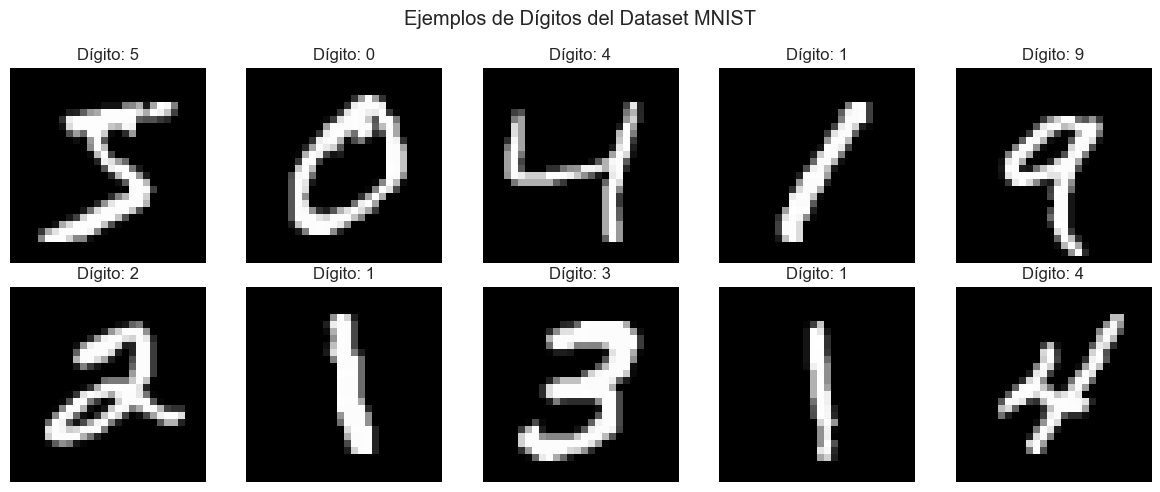

C:\Users\Alumno_AI\AppData\Local\Temp\ipykernel_15428\923325244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_full, palette="viridis")


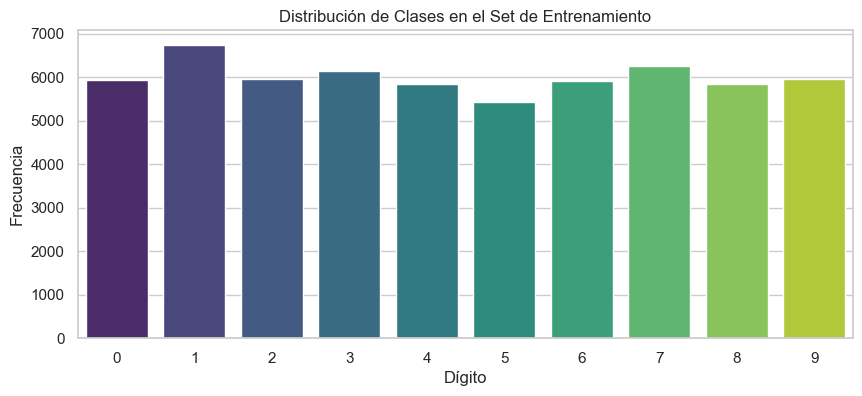

Distribución numérica:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [14]:
# Visualizar múltiples muestras de dígitos
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.title(f"Dígito: {y_train_full[i]}")
    plt.axis('off')
plt.suptitle("Ejemplos de Dígitos del Dataset MNIST")
plt.tight_layout()
plt.show()

# Analizar la distribución de las clases
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train_full, palette="viridis")
plt.title("Distribución de Clases en el Set de Entrenamiento")
plt.xlabel("Dígito")
plt.ylabel("Frecuencia")
plt.show()

print("Distribución numérica:")
unique, counts = np.unique(y_train_full, return_counts=True)
print(dict(zip(unique, counts)))

### 3.3 Limpieza y Preprocesamiento
- **Normalización:** Escalamos los valores de los píxeles de [0, 255] a [0, 1] para mejorar la convergencia del modelo.
- **Reshape:** Las CNN esperan una entrada de 4 dimensiones (samples, height, width, channels). Añadimos el canal 1 para escala de grises.

In [15]:
# Normalización
x_train_full = x_train_full.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Cambio de forma para la CNN (28x28x1)
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# División en Entrenamiento (70%), Validación (15%) y Prueba (15%)
# Ya tenemos x_test (10k), dividimos x_train_full para obtener validación
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f"Dataset dividido en:\n- Train: {x_train.shape[0]}\n- Validation: {x_val.shape[0]}\n- Test: {x_test.shape[0]}")

Dataset dividido en:
- Train: 51000
- Validation: 9000
- Test: 10000


## 4. Model Planning (Planificación del Modelo)

### 4.1 Definición de la Arquitectura
Diseñamos una CNN con la siguiente estructura:
1. **Conv2D + ReLU:** Detector de características (bordes).
2. **MaxPooling2D:** Reducción de dimensionalidad y ruido.
3. **Conv2D + ReLU:** Detector de patrones más complejos.
4. **MaxPooling2D:** Segunda reducción.
5. **Flatten:** Conversión de mapas de características 2D a vector.
6. **Dense:** Capas de clasificación.
7. **Dropout:** Regularización para prevenir el sobreajuste (overfitting).

In [16]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Clasificador
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Desactiva el 50% de neuronas aleatoriamente durante el entrenamiento
    layers.Dense(10, activation='softmax') # Probabilidades para cada dígito (0-9)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,858 (620.54 KB)

 Trainable params: 158,858 (620.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Building and Training (Construcción y Entrenamiento)

Entrenamos el modelo utilizando un flujo claro, monitorizando métricas y aplicando **Early Stopping** para evitar que el modelo aprenda de memoria el set de entrenamiento.

In [17]:
# Callback para detener el entrenamiento si la pérdida en validación deja de mejorar
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9067 - loss: 0.3080 - val_accuracy: 0.9759 - val_loss: 0.0792
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9708 - loss: 0.1049 - val_accuracy: 0.9852 - val_loss: 0.0549
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9790 - loss: 0.0739 - val_accuracy: 0.9874 - val_loss: 0.0490
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9831 - loss: 0.0586 - val_accuracy: 0.9884 - val_loss: 0.0456
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9853 - loss: 0.0501 - val_accuracy: 0.9877 - val_loss: 0.0432
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9877 - loss: 0.0425 - val_accuracy: 0.9894 - val_loss: 0.0430
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9900 - val_loss: 0.0392
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9900 - loss: 0.0332 - val_accu

## 6. Evaluación y Resultados

### 6.1 Análisis Cuantitativo
Visualizamos las curvas de pérdida y precisión.

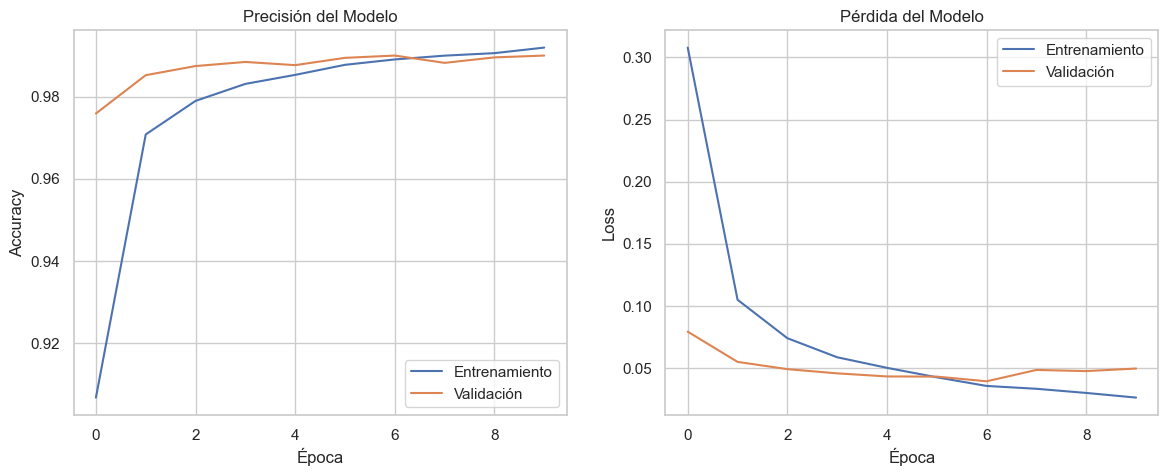

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 6.2 Matriz de Confusión
Analizamos qué dígitos se confunden más frecuentemente entre sí.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


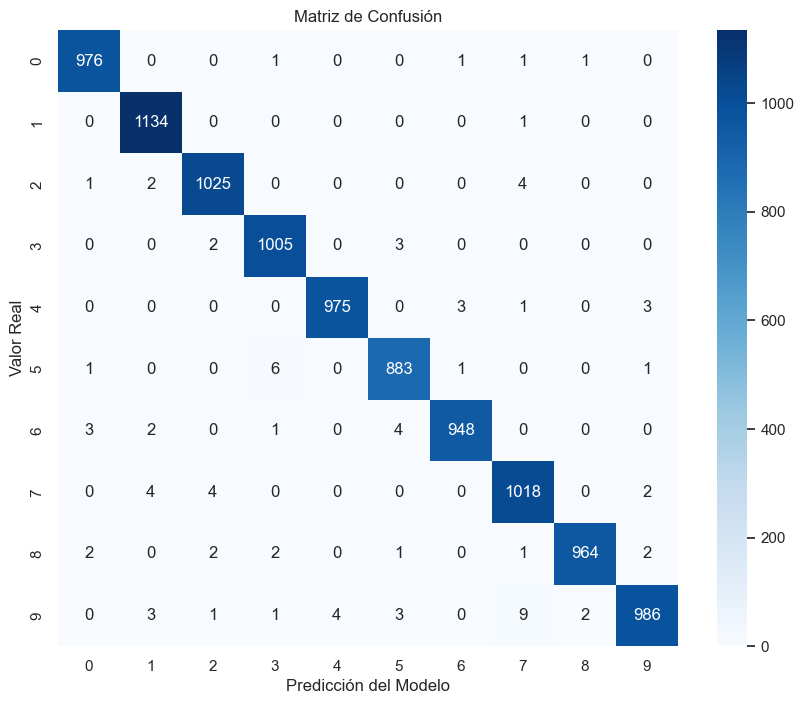

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [19]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

### 6.3 Análisis de Errores
Visualizamos casos donde el modelo falló para entender la variabilidad de las imágenes.

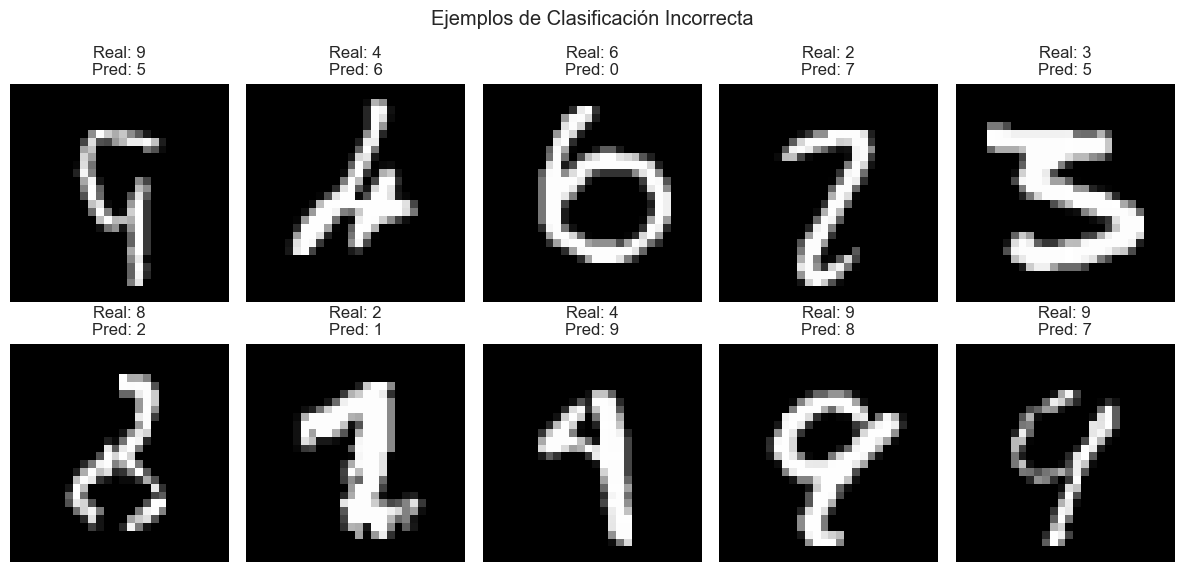

In [20]:
error_indices = np.where(y_pred != y_test)[0]
plt.figure(figsize=(12, 6))
for i, idx in enumerate(error_indices[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.suptitle("Ejemplos de Clasificación Incorrecta")
plt.tight_layout()
plt.show()

### 6.4 Prueba Interactiva del Modelo

En esta sección podemos comprobar si la CNN realmente ha aprendido a reconocer dígitos.

Seleccionamos imágenes aleatorias del conjunto de test y observamos qué predice el modelo.

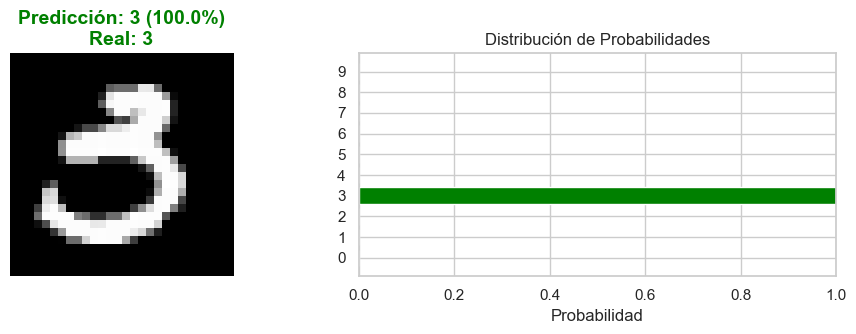

  Imagen #8362: ✅ CORRECTO



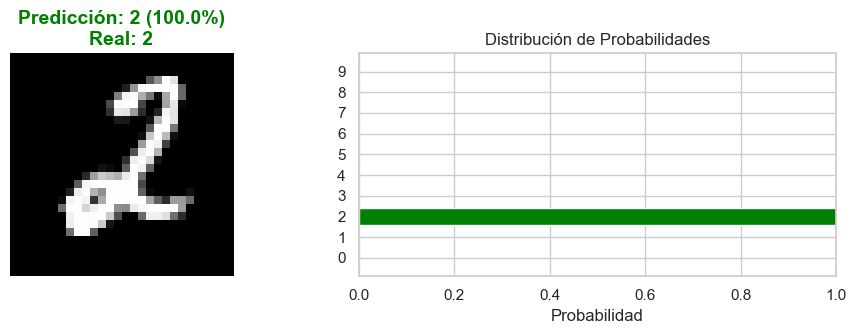

  Imagen #2391: ✅ CORRECTO



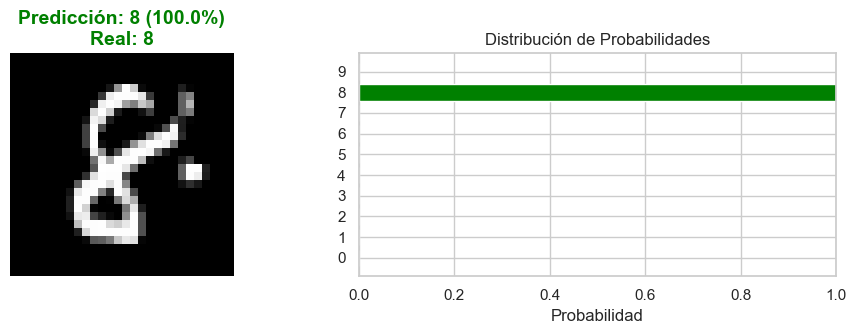

  Imagen #6403: ✅ CORRECTO



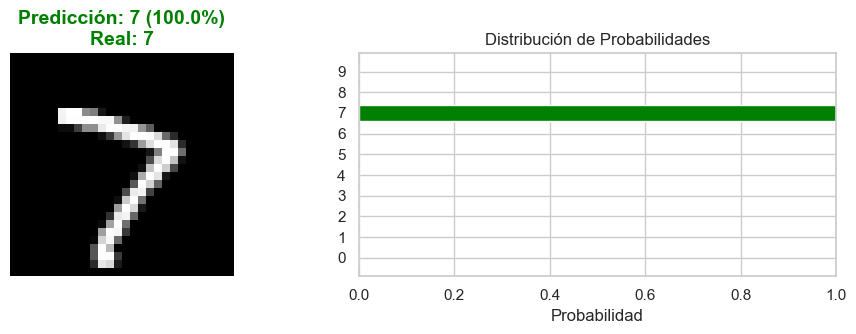

  Imagen #2278: ✅ CORRECTO



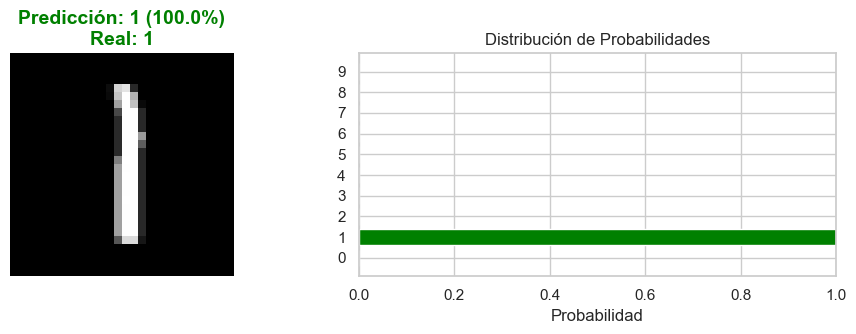

  Imagen #2316: ✅ CORRECTO



In [21]:
# Número de imágenes aleatorias a probar
num_pruebas = 5

# Seleccionar índices aleatorios del conjunto de test
indices = np.random.choice(len(x_test), size=num_pruebas, replace=False)

for idx in indices:
    imagen = x_test[idx]
    etiqueta_real = y_test[idx]

    # Predecir
    probabilidades = model.predict(np.expand_dims(imagen, axis=0), verbose=0)[0]
    prediccion = np.argmax(probabilidades)
    confianza = probabilidades[prediccion] * 100

    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    # Imagen del dígito
    axes[0].imshow(imagen.reshape(28, 28), cmap='gray')
    acierto = prediccion == etiqueta_real
    color = 'green' if acierto else 'red'
    axes[0].set_title(
        f'Predicción: {prediccion} ({confianza:.1f}%)\nReal: {etiqueta_real}',
        fontsize=14, color=color, fontweight='bold'
    )
    axes[0].axis('off')

    # Gráfico de barras con probabilidades por clase
    colores = ['#cccccc'] * 10
    colores[prediccion] = color
    axes[1].barh(range(10), probabilidades, color=colores)
    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels([str(i) for i in range(10)])
    axes[1].set_xlabel('Probabilidad')
    axes[1].set_title('Distribución de Probabilidades')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    resultado = "✅ CORRECTO" if acierto else "❌ INCORRECTO"
    print(f"  Imagen #{idx}: {resultado}\n")


## 7. Deployment (Despliegue)

Serializamos el modelo para poder cargarlo en un entorno de producción (ej. una API con FastAPI o una interfaz con Streamlit).

In [22]:
model_name = 'modelo_digitos_cnn_final.keras'
model.save(model_name)
print(f"Modelo guardado exitosamente como {model_name}")

Modelo guardado exitosamente como modelo_digitos_cnn_final.keras
